# OpenScope Ophys Motion QC

| Stage | Scope | Goal |
|-------|-------|------|
| **1** | Single session | Load raw motion data and inspect every metric in detail |
| **2** | Multiple sessions | Scale to a sample of the full dataset and assess population-level quality |

## Shared Setup

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, "../src")

import motion_loader
import motion_plots
import motion_qc
import roi_classifier
import roi_plots
import scatter_plots
import session_loader as sl
import zdrift_plots

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 100)

FIGURES_DIR = Path("outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

---
# Stage 1 — Single Session

Establishes ground truth on one well-characterized session: loads the raw motion data,
computes displacement and registration metrics plane by plane, and visualizes the full
temporal structure before scaling up to the population.

**Contents**
- 1.1 Configuration
- 1.2 Load session
- 1.3 Motion data
- 1.4 Figures
- 1.5 Summary statistics

### 1.1 Configuration

In [2]:
SESSION_SOURCE = (
    "s3://aind-open-data/"
    "multiplane-ophys_837568_2026-03-05_14-14-51_processed_2026-03-06_11-31-22"
)

OUT_DIR_S1 = Path("outputs/stage1")
OUT_DIR_S1.mkdir(parents=True, exist_ok=True)

print("Session:", SESSION_SOURCE)

Session: s3://aind-open-data/multiplane-ophys_837568_2026-03-05_14-14-51_processed_2026-03-06_11-31-22


### 1.2 Load Session

Loads the NWB file and plane metadata for the configured session.

In [3]:
import json

session    = sl.load_session(SESSION_SOURCE)
nwb        = session["nwb"]
plane_meta = session["plane_meta"]
planes     = session["planes"]
meta       = session["meta"]

(OUT_DIR_S1 / "session_metadata.json").write_text(
    json.dumps(meta, indent=2), encoding="utf-8"
)

subj = meta.get("subject", {})
display(pd.DataFrame([{
    "session_id" : meta.get("session_id"),
    "subject_id" : subj.get("subject_id"),
    "genotype"   : subj.get("genotype"),
    "sex"        : subj.get("sex"),
    "age"        : subj.get("age"),
    "n_planes"   : len(meta.get("imaging_planes", [])),
}]))
display(plane_meta)

,session_id,subject_id,genotype,sex,age,n_planes
0,multiplane-ophys_837568_2026-03-05_14-14-51,837568,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,M,P121D,8


,plane,structure,depth_um,location,imaging_rate_hz,excitation_lambda_nm,indicator,device
0,VISl_4,VISl,173.0,Structure: VISl Depth: 173,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
1,VISl_5,VISl,297.0,Structure: VISl Depth: 297,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
2,VISl_6,VISl,57.0,Structure: VISl Depth: 57,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
3,VISl_7,VISl,384.0,Structure: VISl Depth: 384,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
4,VISp_0,VISp,184.0,Structure: VISp Depth: 184,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
5,VISp_1,VISp,271.0,Structure: VISp Depth: 271,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
6,VISp_2,VISp,60.0,Structure: VISp Depth: 60,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
7,VISp_3,VISp,380.0,Structure: VISp Depth: 380,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1


### 1.3 Motion Data

Loads per-frame x/y displacement offsets, frame-to-template correlation, and validity
flags for every imaging plane from the S3 motion-correction CSVs.

In [4]:
motion_data = motion_loader.load_motion_data(SESSION_SOURCE)

Session  : multiplane-ophys_837568_2026-03-05_14-14-51
Planes   : ['VISl_4', 'VISl_5', 'VISl_6', 'VISl_7', 'VISp_0', 'VISp_1', 'VISp_2', 'VISp_3']
  VISl_4 ✓  median=1.74 µm  invalid=0/41307
  VISl_5 ✓  median=1.74 µm  invalid=0/41307
  VISl_6 ✓  median=1.10 µm  invalid=0/41307
  VISl_7 ✓  median=2.21 µm  invalid=0/41307
  VISp_0 ✓  median=2.81 µm  invalid=0/41307
  VISp_1 ✓  median=2.34 µm  invalid=0/41307
  VISp_2 ✓  median=2.47 µm  invalid=0/41307
  VISp_3 ✓  median=2.47 µm  invalid=0/41307


### 1.4 Figures

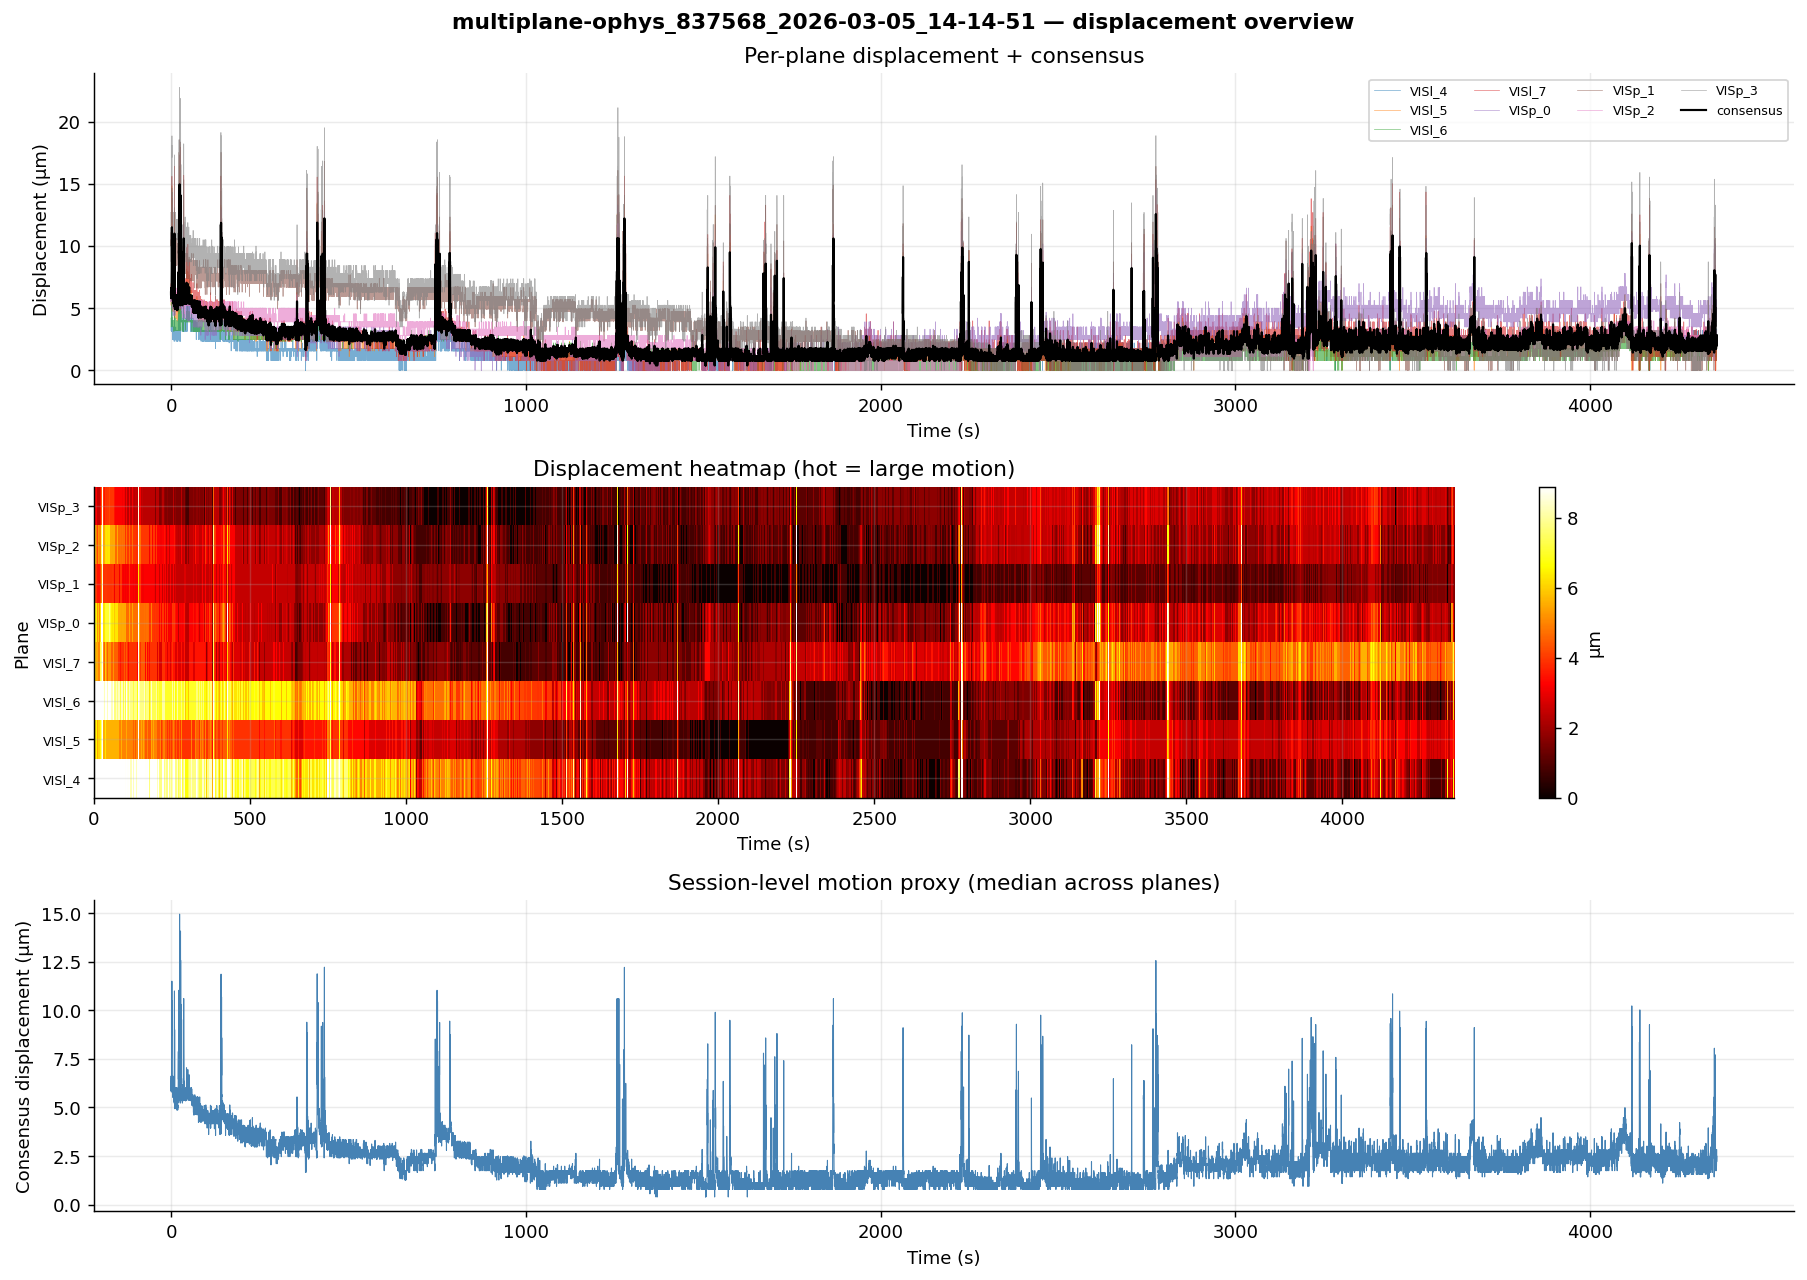

In [5]:
fig = motion_plots.plot_displacement_traces(
    motion_data, save_dir=OUT_DIR_S1
)
plt.show()
plt.close(fig)

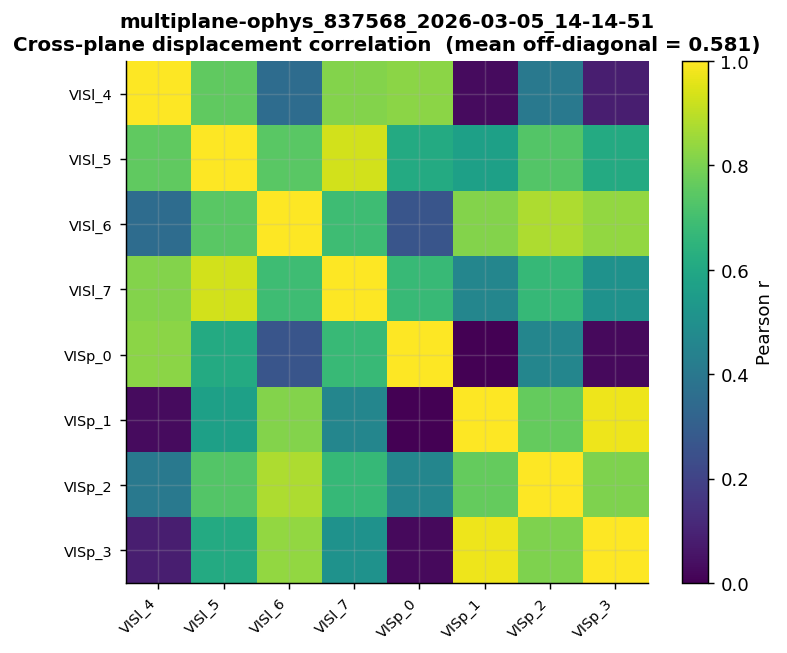

In [6]:
fig = motion_plots.plot_cross_plane_corr(
    motion_data, save_dir=OUT_DIR_S1
)
plt.show()
plt.close(fig)

### 1.5 Summary Statistics

One row per plane: 
* median
* P95
* maximum displacement
* bad-frame
* invalid-frame fractions
* mean registration correlation.

In [9]:
rows = []
for plane, df in motion_data["planes"].items():
    rows.append({
        "plane"          : plane,
        "n_frames"       : len(df),
        "median_disp_um" : round(df["displacement_um"].median(), 3),
        "p95_disp_um"    : round(df["displacement_um"].quantile(0.95), 3),
        "max_disp_um"    : round(df["displacement_um"].max(), 3),
        "bad_frame_frac" : round((df["displacement_um"] > 5.0).mean(), 4),
        "invalid_frac"   : round((~df["is_valid"]).mean(), 4),
        "mean_reg_corr"  : round(df["correlation"].mean(), 4),
    })

stats_df = pd.DataFrame(rows)
stats_df.to_csv(OUT_DIR_S1 / "motion_plane_stats.csv", index=False)
display(stats_df)

,plane,n_frames,median_disp_um,p95_disp_um,max_disp_um,bad_frame_frac,invalid_frac,mean_reg_corr
0,VISl_4,41307,1.744,3.309,11.700,0.0070,0.0,0.0187
1,VISl_5,41307,1.744,3.977,16.399,0.0263,0.0,0.0227
2,VISl_6,41307,1.103,3.216,9.489,0.0042,0.0,0.0155
3,VISl_7,41307,2.206,4.745,17.940,0.0414,0.0,0.0153
4,VISp_0,41307,2.812,5.625,14.902,0.1031,0.0,0.0166
5,VISp_1,41307,2.340,7.800,18.540,0.2348,0.0,0.0182
6,VISp_2,41307,2.467,4.994,12.697,0.0282,0.0,0.0140
7,VISp_3,41307,2.467,8.893,22.741,0.2732,0.0,0.0115


---
# Stage 2 — Multi-Session

Scales the Stage 1 analysis across a random sample of the full dataset.
Motion stability and ROI classification quality are computed independently
for each session and plane, then joined to test whether image quality
predicts cell-type yield.

**Contents**
- 2.1 Discover sessions
- 2.2 Compute motion QC
- 2.3 Compute ROI quality
- 2.4 Merge
- 2.5 Figures
- 2.6 Summary statistics

---

### Motion Metrics

| Metric | Description |
|--------|-------------|
| `median_disp_um` | Median per-frame displacement in microns; the primary measure of overall motion level. |
| `mean_disp_um` | Mean displacement; more sensitive to large excursions than the median. |
| `p95_disp_um` | 95th-percentile displacement; characterizes the severity of the worst motion without using the single largest frame. |
| `p99_disp_um` | 99th-percentile displacement; captures near-maximum motion while remaining robust to single outlier frames. |
| `max_disp_um` | Largest single-frame displacement observed in the session. |
| `displacement_cv` | Coefficient of variation (std / mean) of displacement; high values indicate bursty rather than sustained motion. |
| `bad_frame_frac` | Fraction of frames exceeding 5 µm displacement; directly quantifies how much data is likely contaminated. |
| `invalid_frame_frac` | Fraction of frames flagged as invalid by suite2p's internal quality filter. |
| `mean_reg_corr` | Mean Pearson correlation between each frame and the registration template; low values indicate poor motion correction. |
| `median_reg_corr` | Median frame-to-template correlation; robust central tendency of registration quality. |
| `min_reg_corr` | Worst single-frame registration correlation in the session. |
| `std_reg_corr` | Standard deviation of frame correlations; high values suggest intermittent registration failures. |
| `first_5min_median_um` | Median displacement during the first five minutes; captures the initial brain-settling period. |
| `last_5min_median_um` | Median displacement during the last five minutes; reflects motion once the brain has settled. |
| `early_late_ratio` | Ratio of first to last 5-minute median; values above 1 indicate the session improved over time. |
| `displacement_slope_um_per_min` | Linear trend of displacement over the session in µm/min; positive values indicate progressive worsening. |
| `settling_time_s` | Time in seconds until displacement stays below 3 µm for 60 consecutive seconds. |
| `n_motion_bursts` | Number of discrete high-motion events above 5 µm after dilation; distinguishes many small events from few large ones. |
| `longest_clean_run_s` | Duration in seconds of the longest uninterrupted epoch below 5 µm; a direct lower bound on usable recording time. |
| `z_drift_um` | Axial drift from session start to end in µm; can shift the focal plane off target neurons. |
| `intensity_stability_pct` | Fluorescence intensity stability percentage; drops may reflect photobleaching or focal-plane drift. |

### ROI Classification Targets

| Metric | Description |
|--------|-------------|
| `mean_soma_prob` | Mean probability across all ROIs that a given ROI is a cell body; the primary target for assessing segmentation quality. |
| `mean_dendrite_prob` | Mean probability across all ROIs that a given ROI is a dendrite process; elevated values may indicate over-segmentation of neuropil. |

### 2.1 Discover Sessions

Lists every multiplane-ophys processed asset in the S3 bucket.

In [10]:
OUT_DIR_S2 = Path("outputs/stage2")
OUT_DIR_S2.mkdir(parents=True, exist_ok=True)

all_paths = sl.discover_sessions()
print(f"Found {len(all_paths)} sessions")
for p in all_paths[:5]:
    print(" ", p)
if len(all_paths) > 5:
    print(f"  … and {len(all_paths) - 5} more")

Found 372 sessions
  s3://aind-open-data/multiplane-ophys_775682_2025-03-03_09-39-23_processed_2025-03-04_17-19-32
  s3://aind-open-data/multiplane-ophys_779190_2025-03-03_13-36-14_processed_2025-03-04_16-38-10
  s3://aind-open-data/multiplane-ophys_800792_2025-11-06_11-00-52_processed_2025-11-07_13-53-38
  s3://aind-open-data/multiplane-ophys_800792_2025-11-07_11-04-07_processed_2025-11-08_12-40-04
  s3://aind-open-data/multiplane-ophys_800792_2025-11-11_09-26-07_processed_2025-11-12_12-35-00
  … and 367 more


### 2.2 Compute Motion QC

For each session × plane, reads the motion-correction CSV from S3 and derives
the full set of motion metrics defined in the table above.
Results are saved to `outputs/stage2/motion_plane_metrics.csv` and
`outputs/stage2/motion_session_metrics.csv`.

In [11]:
SAMPLE_SIZE = 10
RANDOM_SEED = 42

plane_df, session_df = motion_qc.run(
    all_paths, n=SAMPLE_SIZE, seed=RANDOM_SEED, out_dir=OUT_DIR_S2
)

Running motion QC on 10 sessions

[1/10] multiplane-ophys_843168_2026-04-22_11-54-32
  ✗  no planes found
[2/10] multiplane-ophys_818629_2025-12-12_11-42-25
  planes: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
    VISp_0 ✓  median=1.10 µm  bad_frac=0.042
    VISp_1 ✓  median=1.10 µm  bad_frac=0.066
    VISp_2 ✓  median=2.47 µm  bad_frac=0.002
    VISp_3 ✓  median=1.10 µm  bad_frac=0.045
    VISp_4 ✓  median=2.34 µm  bad_frac=0.001
    VISp_5 ✓  median=1.10 µm  bad_frac=0.052
    VISp_6 ✓  median=2.47 µm  bad_frac=0.001
    VISp_7 ✓  median=1.10 µm  bad_frac=0.060
  → session median_disp=1.10 µm  cross_plane_corr=0.564

[3/10] multiplane-ophys_806644_2025-10-24_11-04-57
  planes: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
    VISp_0 ✓  median=3.22 µm  bad_frac=0.316
    VISp_1 ✓  median=5.94 µm  bad_frac=0.587
    VISp_2 ✓  median=5.62 µm  bad_frac=0.551
    VISp_3 ✓  median=6.09 µm  bad_frac=0.603
    VISp_4 ✓ 

### 2.3 Compute ROI Quality

For each session × plane, opens the NWB Zarr file and reads the suite2p
segmentation table, extracting per-ROI soma and dendrite classification
scores produced by the Allen Institute's classifier.
Results are saved to `outputs/stage2/roi_classifications.csv` and
`outputs/stage2/roi_plane_summary.csv`.

In [12]:
roi_df, summary_df = roi_classifier.run(
    all_paths, n=SAMPLE_SIZE, seed=RANDOM_SEED, out_dir=OUT_DIR_S2
)

Extracting ROI classifications from 10 sessions

[1/10] multiplane-ophys_843168_2026-04-22_11-54-32
  opening multiplane-ophys_843168_2026-04-22_11-54-32_processed_2026-04-23_06-16-11 ... ✗  (nothing found at path '')

[2/10] multiplane-ophys_818629_2025-12-12_11-42-25
  opening multiplane-ophys_818629_2025-12-12_11-42-25_processed_2025-12-13_19-01-56 ... ✗  (nothing found at path '')

[3/10] multiplane-ophys_806644_2025-10-24_11-04-57
  opening multiplane-ophys_806644_2025-10-24_11-04-57_processed_2025-10-25_18-22-02 ... ✗  (nothing found at path '')

[4/10] multiplane-ophys_823831_2026-01-31_09-39-48
  opening multiplane-ophys_823831_2026-01-31_09-39-48_processed_2026-02-01_17-38-08 ... ✓  planes: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
    VISp_0: 91 ROIs  76 soma (84%)  mean soma_prob=0.839
    VISp_1: 79 ROIs  60 soma (76%)  mean soma_prob=0.760
    VISp_2: 89 ROIs  77 soma (87%)  mean soma_prob=0.853
    VISp_3: 65 ROIs  54 soma (83%)  mea

### 2.4 Merge

Joins motion metrics and ROI quality scores on session_id × plane,
producing one row per session × plane with all columns present.

In [13]:
merged_df = scatter_plots.merge(plane_df, summary_df)

print(f"Merged shape: {merged_df.shape}")
print(f"ROI columns present: {merged_df['mean_soma_prob'].notna().sum()} / {len(merged_df)} rows")

Merged shape: (72, 36)
ROI columns present: 32 / 72 rows


### 2.5 Figures

All figures are saved to `outputs/stage2/figures/`.

#### Motion Figures

Session- and plane-level views of displacement, registration quality, z-drift,
and temporal stability across the sampled population.

In [14]:
motion_figs = motion_plots.plot_all(
    plane_df, session_df,
    save_dir=OUT_DIR_S2 / "figures" / "motion",
)

Saving motion QC figures to outputs\stage2\figures\motion/

  median_vs_p95 ... ✓
  bad_frame_frac_hist ... ✓
  displacement_slope_bar ... ✓
  settling_time_vs_early ... ✓
  early_vs_late ... ✓
  invalid_frame_frac ... ✓
  cross_plane_corr_bar ... ✓
  outlier_plane_count ... ✓
  displacement_by_plane ... ✓
  displacement_by_area ... ✓
  bad_frame_frac_by_plane ... ✓
  zdrift_by_plane ... ✓
  zdrift_vs_lateral ... ✓
  reg_corr_by_plane ... ✓
  reg_corr_vs_displacement ... ✓
  bursts_vs_bad_frame_frac ... ✓
  longest_clean_run ... ✓
  bad_frame_frac_vs_reg_corr ... ✓
  session_plane_heatmap ... ✓
  longitudinal ... ✓ (8 subjects)

Done. 27 figures saved.


#### ROI Classification Figures

Per-plane distributions of ROI yield and soma/dendrite classification confidence
across sessions.

In [15]:
roi_figs = roi_plots.plot_all(
    summary_df,
    save_dir=OUT_DIR_S2 / "figures" / "roi",
)

Saving ROI classification figures to outputs\stage2\figures\roi/

  [01] n_rois ... ✓
  [02] soma_frac ... ✓
  [03] dendrite_frac ... ✓
  [04] mean_soma_prob ... ✓
  [05] median_soma_prob ... ✓
  [06] mean_dendrite_prob ... ✓
  [07] median_dendrite_prob ... ✓

Done. 7/7 figures saved.


#### Cross-Analysis Figures

For each combination of displacement metric and classification target,
a scatter plot with per-area coloring and Pearson r tests whether
motion quality predicts ROI classification outcomes.

In [16]:
scatter_figs = scatter_plots.plot_all(
    merged_df,
    save_dir=OUT_DIR_S2 / "figures" / "scatter",
)

Saving scatter figures to outputs\stage2\figures\scatter/

  mean_soma_prob ... ✓
  mean_dendrite_prob ... ✓

Done. 2/2 figures saved.


#### Z-Drift Case Studies

Displacement overviews and cross-plane correlation matrices for the five sessions
with the largest and smallest axial drift, providing concrete examples at the
extremes of the quality distribution.

In [17]:
zdrift_figs = zdrift_plots.run(
    plane_df, all_paths, n=5,
    save_dir=OUT_DIR_S2 / "figures" / "zdrift_examples",
)

Worst 5 z-drift sessions:
                                 session_id  max_z_drift_um
multiplane-ophys_818322_2025-11-05_13-57-23           13.50
multiplane-ophys_837568_2026-03-09_11-43-41           11.25
multiplane-ophys_806644_2025-10-24_11-04-57           10.50
multiplane-ophys_818629_2025-12-12_11-42-25            6.00
multiplane-ophys_845939_2026-05-14_09-33-35            2.25

Best 5 z-drift sessions:
                                 session_id  max_z_drift_um
multiplane-ophys_845939_2026-05-14_09-33-35            2.25
multiplane-ophys_823831_2026-01-31_09-39-48            1.50
multiplane-ophys_822862_2025-12-03_09-26-21            0.00
multiplane-ophys_823049_2025-11-11_16-03-31            0.00
multiplane-ophys_823049_2025-12-01_14-16-07            0.00

── WORST z-drift sessions ──────────────────────
  loading multiplane-ophys_818322_2025-11-05_13-57-23 ... ✓  (8 planes, 38464 frames)
  loading multiplane-ophys_837568_2026-03-09_11-43-41 ... ✓  (8 planes, 41007 frames)
  load

### 2.6 Summary Statistics

Grand-median and interquartile range for every metric, split by brain area
and aggregated across all sampled sessions.

In [18]:
# Motion metrics — per plane
motion_cols = [
    "median_disp_um", "p95_disp_um", "bad_frame_frac",
    "invalid_frame_frac", "mean_reg_corr", "z_drift_um",
    "intensity_stability_pct", "settling_time_s",
    "n_motion_bursts", "longest_clean_run_s",
]
ok_plane = plane_df[plane_df["error"].isna()] if "error" in plane_df.columns else plane_df

motion_summary = (
    ok_plane
    .groupby("structure")[motion_cols]
    .agg(["median",
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75)])
)
motion_summary.columns = ["_".join(c).replace("<lambda_0>", "q25").replace("<lambda_1>", "q75")
                           for c in motion_summary.columns]
motion_summary.to_csv(OUT_DIR_S2 / "motion_summary_stats.csv")
display(motion_summary.T)

structure,VISl,VISp
median_disp_um_median,1.744133,1.744133
median_disp_um_q25,1.744133,1.103087
median_disp_um_q75,1.859643,2.812330
p95_disp_um_median,4.857931,4.806577
p95_disp_um_q25,4.022388,3.216022
p95_disp_um_q75,5.556196,8.363635
bad_frame_frac_median,0.043712,0.034684
bad_frame_frac_q25,0.021557,0.002309
bad_frame_frac_q75,0.061733,0.282812
invalid_frame_frac_median,0.000000,0.000000


In [19]:
# ROI metrics — per plane
roi_cols = [
    "n_rois", "soma_frac", "dendrite_frac",
    "mean_soma_prob", "mean_dendrite_prob",
]
ok_summary = summary_df if "error" not in summary_df.columns else summary_df[summary_df["error"].isna()]

roi_summary = (
    ok_summary
    .groupby("structure")[roi_cols]
    .agg(["median",
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75)])
)
roi_summary.columns = ["_".join(c).replace("<lambda_0>", "q25").replace("<lambda_1>", "q75")
                        for c in roi_summary.columns]
roi_summary.to_csv(OUT_DIR_S2 / "roi_summary_stats.csv")
display(roi_summary.T)

structure,VISl,VISp
n_rois_median,260.000000,90.000000
n_rois_q25,144.250000,57.000000
n_rois_q75,364.500000,427.000000
soma_frac_median,0.206417,0.832967
soma_frac_q25,0.183507,0.721372
soma_frac_q75,0.219237,0.886611
dendrite_frac_median,0.793583,0.167033
dendrite_frac_q25,0.780763,0.113389
dendrite_frac_q75,0.816493,0.278628
mean_soma_prob_median,0.207272,0.822366
